In [63]:
import sys
sys.path.insert(0, "src")

In [64]:
import json
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import pandas as pd
import requests
import seaborn as sns
from shapely.geometry import LineString, Point
from profiles import Profile, Archetype

In [65]:
with open("artifacts/filtered_profiles.json") as file:
    profles_json = json.load(file)
filtered_profiles = [Profile.model_validate(profile_json) for profile_json in profles_json]

profiles_by_archetype = [
    (archetype, [profile for profile in filtered_profiles if profile.archetype == archetype])
    for archetype in Archetype
]

In [66]:
TIGER_DIR = Path("artifacts/tiger")
TIGER_DIR.mkdir(parents = True, exist_ok = True)
STATE_FIPS = {"11", "24", "51"}

TIGER_FILES = {
    "state": "https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip",
    "county": "https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip"
}

def fetch_tiger(name: str, url: str) -> Path:
    path = TIGER_DIR / f"{name}.zip"
    if path.exists():
        return path
    response = requests.get(url, stream = True, timeout = 120)
    response.raise_for_status()
    with open(path, "wb") as file:
        for chunk in response.iter_content(chunk_size = 1 << 16):
            file.write(chunk)
    return path

state_path = fetch_tiger("state", TIGER_FILES["state"])
county_path = fetch_tiger("county", TIGER_FILES["county"])

states_gdf = gpd.read_file(f"zip://{state_path}").to_crs("EPSG:4326")
states_gdf = states_gdf[states_gdf["STATEFP"].isin(STATE_FIPS)]

counties_gdf = gpd.read_file(f"zip://{county_path}").to_crs("EPSG:4326")
counties_gdf = counties_gdf[counties_gdf["STATEFP"].isin(STATE_FIPS)]

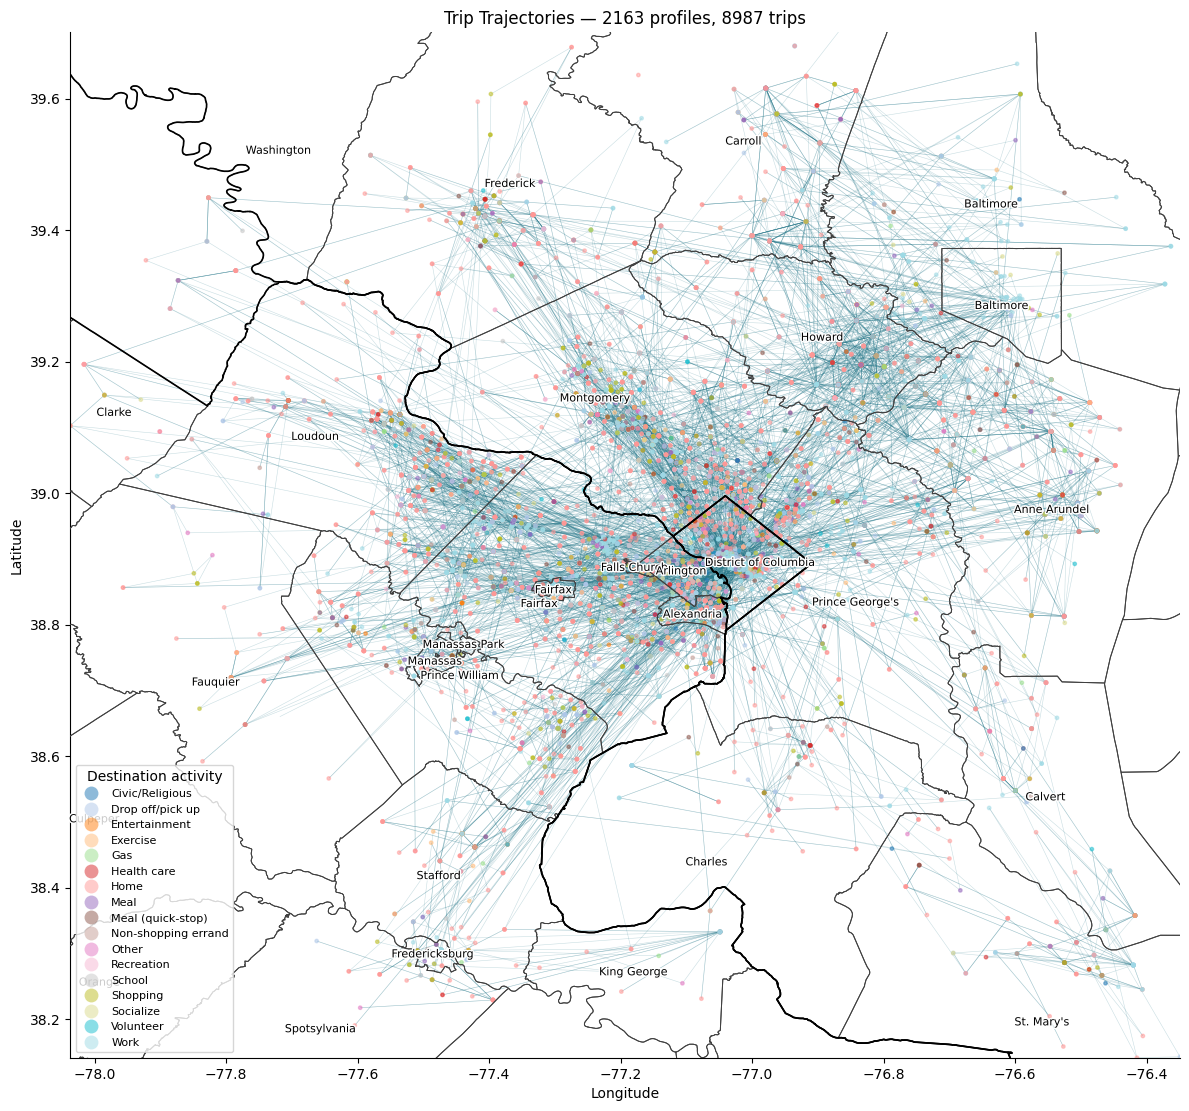

In [67]:
def plot_trip_geo(profiles: list[Profile], title_prefix: str = "Trip Trajectories") -> None:
    qualifying = [
        profile for profile in profiles
        if all(trip.origin_coords is not None and trip.dest_coords is not None for trip in profile.trips)
    ]

    lines = [
        LineString([trip.origin_coords, trip.dest_coords])
        for profile in qualifying
        for trip in profile.trips
    ]
    if not lines:
        return

    gdf = gpd.GeoDataFrame(geometry = lines, crs = "EPSG:4326")

    dest_records = [
        {"activity": trip.dest_activity, "geometry": Point(trip.dest_coords)}
        for profile in qualifying
        for trip in profile.trips
        if trip.dest_activity is not None
    ]
    dest_gdf = gpd.GeoDataFrame(dest_records, crs = "EPSG:4326")

    trip_min_x, trip_min_y, trip_max_x, trip_max_y = gdf.total_bounds
    pad = 0.5
    filter_min_x = trip_min_x - pad
    filter_min_y = trip_min_y - pad
    filter_max_x = trip_max_x + pad
    filter_max_y = trip_max_y + pad

    counties_view = counties_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]
    states_view = states_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]
    dest_view = dest_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]

    fig, ax = plt.subplots(figsize = (12, 12))
    gdf.plot(ax = ax, color = sns.color_palette("crest")[3], linewidth = 0.4, alpha = 0.25, zorder = 1)
    dest_view.plot(
        ax = ax,
        column = "activity",
        categorical = True,
        cmap = "tab20",
        markersize = 6,
        alpha = 0.5,
        legend = True,
        legend_kwds = {"loc": "lower left", "fontsize": 8, "title": "Destination activity"},
        zorder = 2
    )
    counties_view.boundary.plot(ax = ax, color = "#404040", linewidth = 0.7, zorder = 3)
    states_view.boundary.plot(ax = ax, color = "black", linewidth = 1.2, zorder = 4)
    for _, county_row in counties_view.iterrows():
        point = county_row.geometry.representative_point()
        ax.annotate(
            county_row["NAME"],
            xy = (point.x, point.y),
            ha = "center",
            va = "center",
            fontsize = 8,
            color = "black",
            zorder = 5,
            path_effects = [pe.withStroke(linewidth = 2, foreground = "white")]
        )

    ax.set_xlim(trip_min_x, trip_max_x)
    ax.set_ylim(trip_min_y, trip_max_y)
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title_prefix} — {len(qualifying)} profiles, {len(lines)} trips")
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_trip_geo(filtered_profiles)

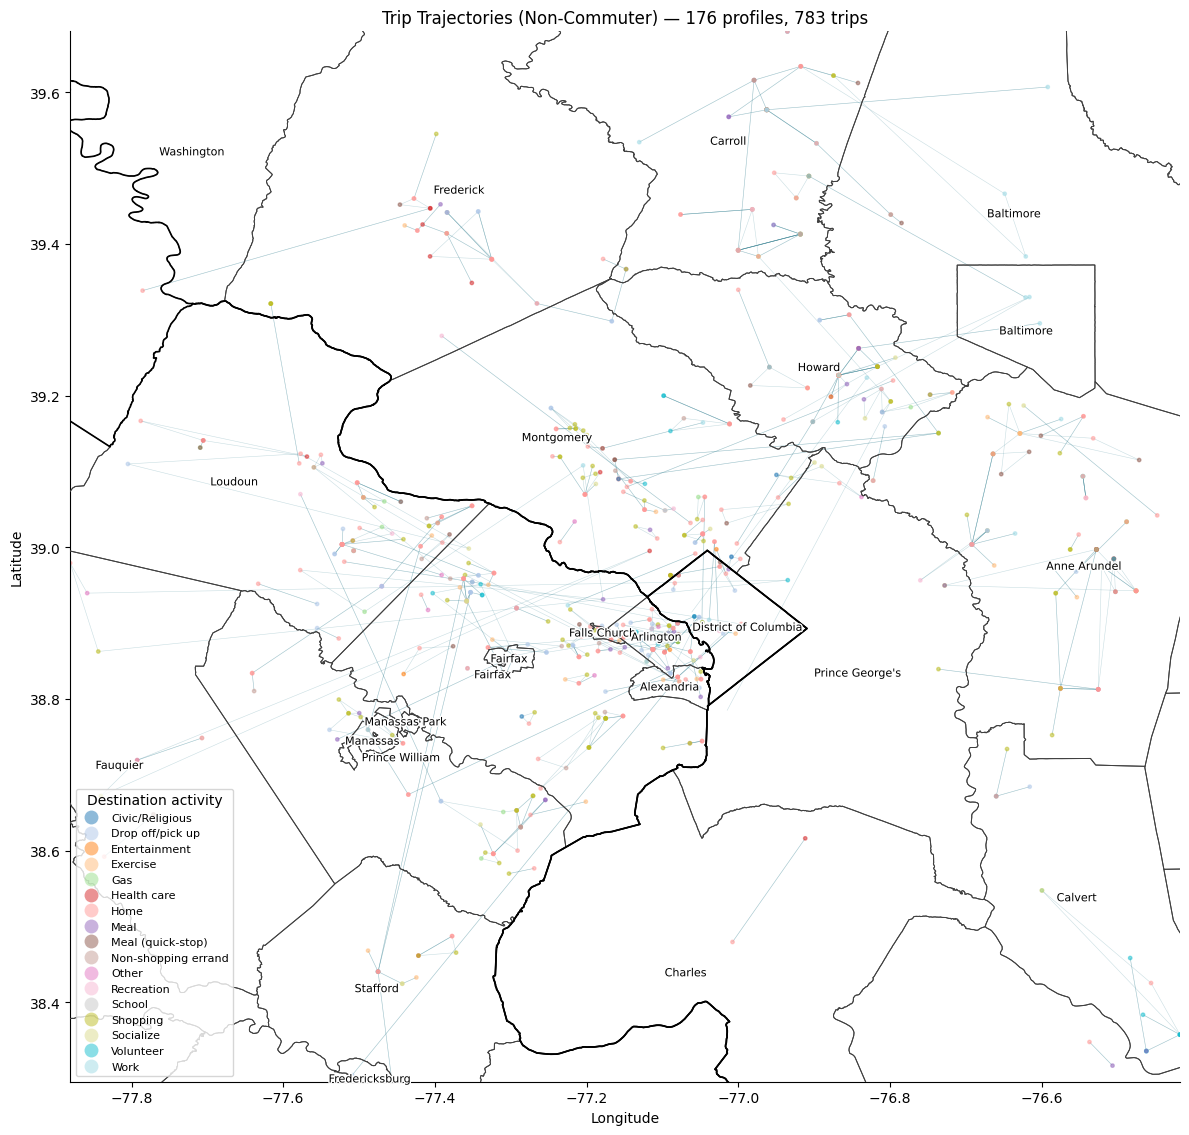

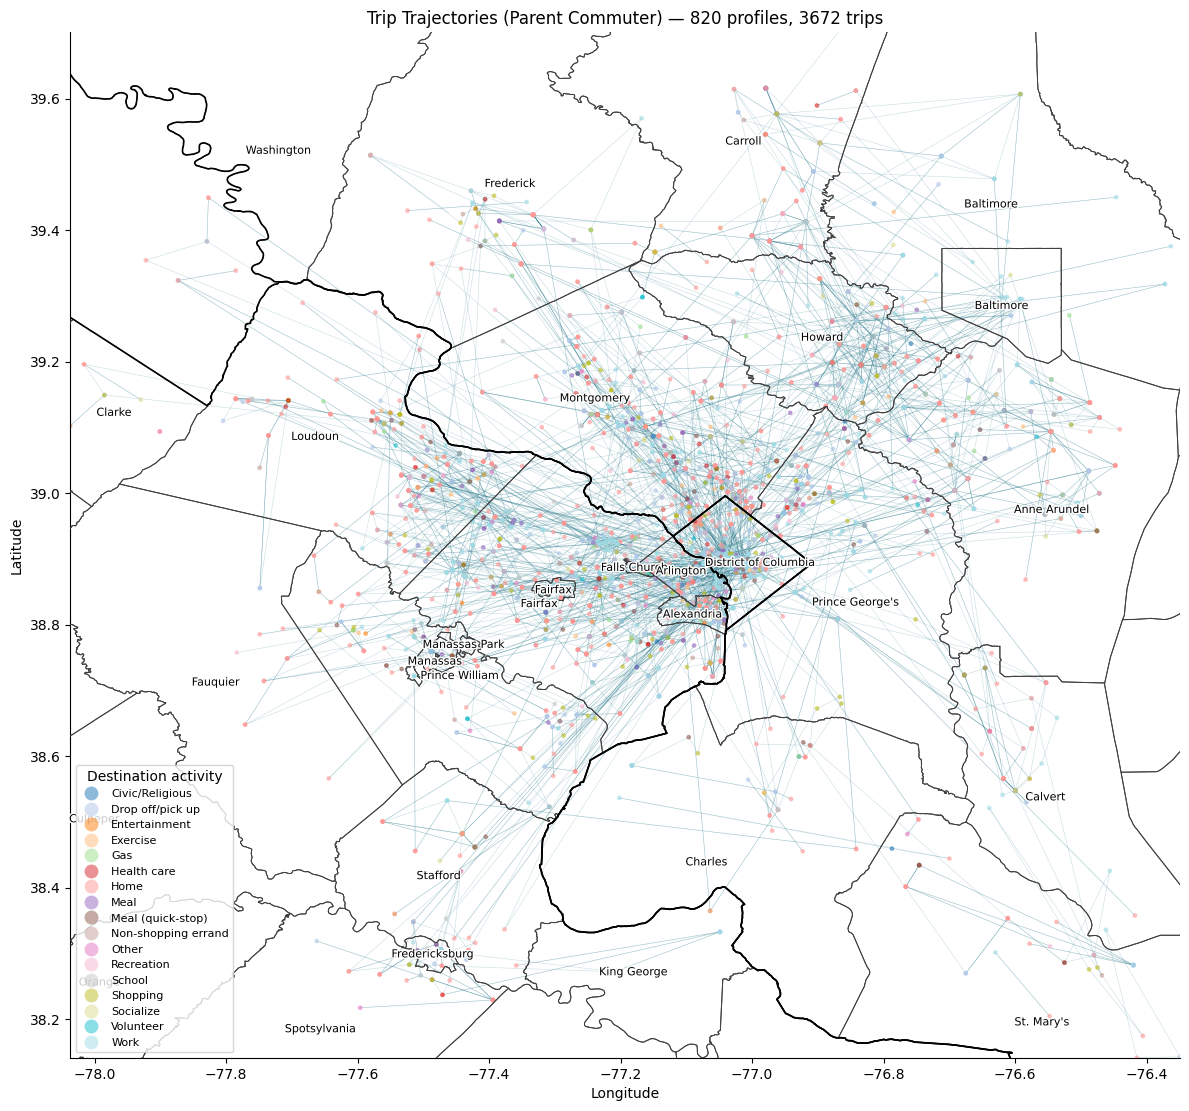

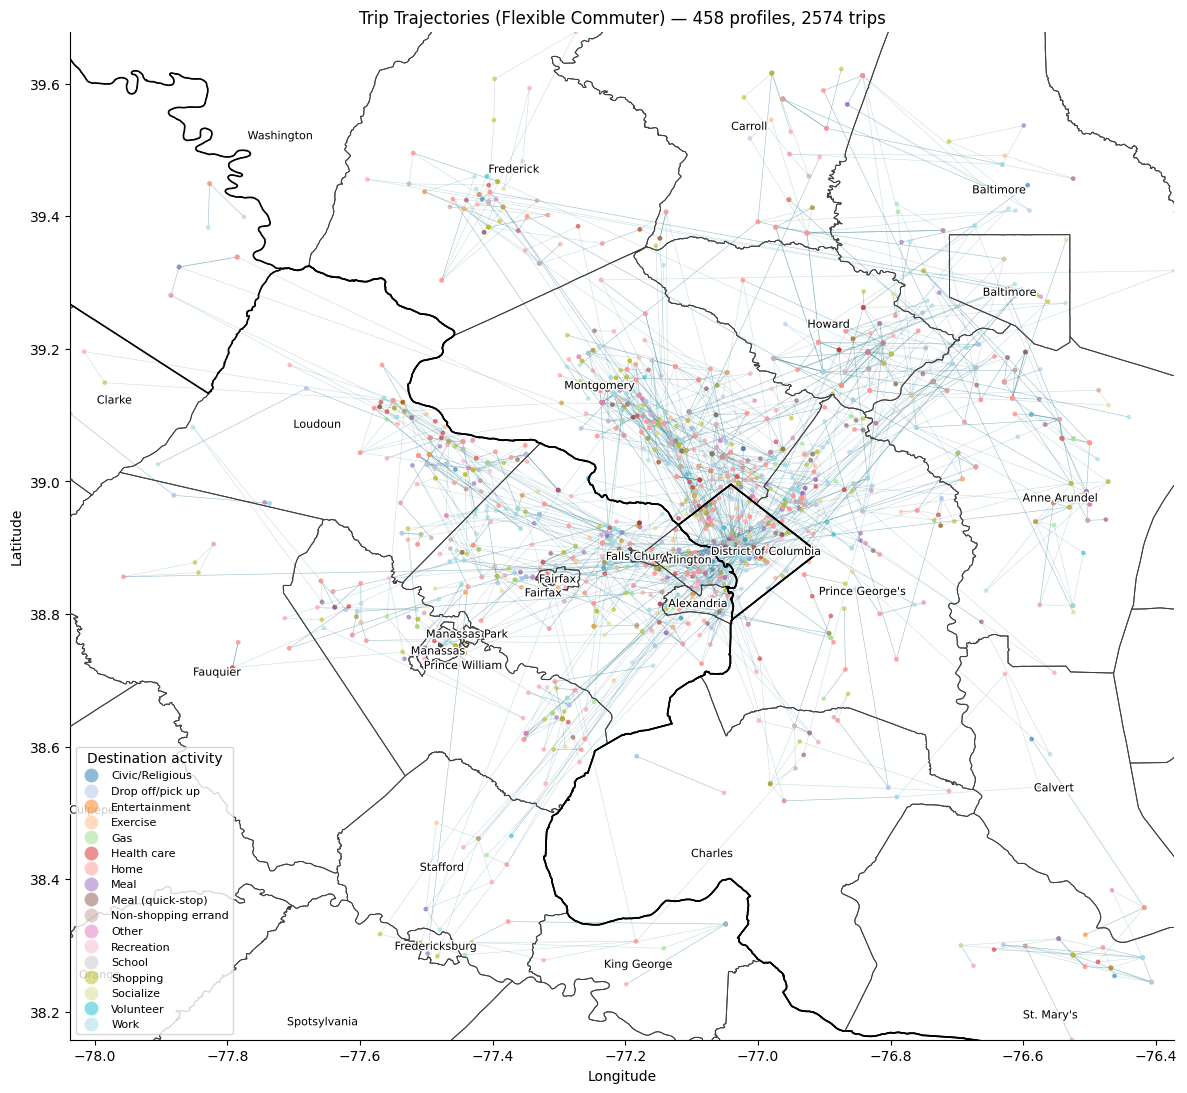

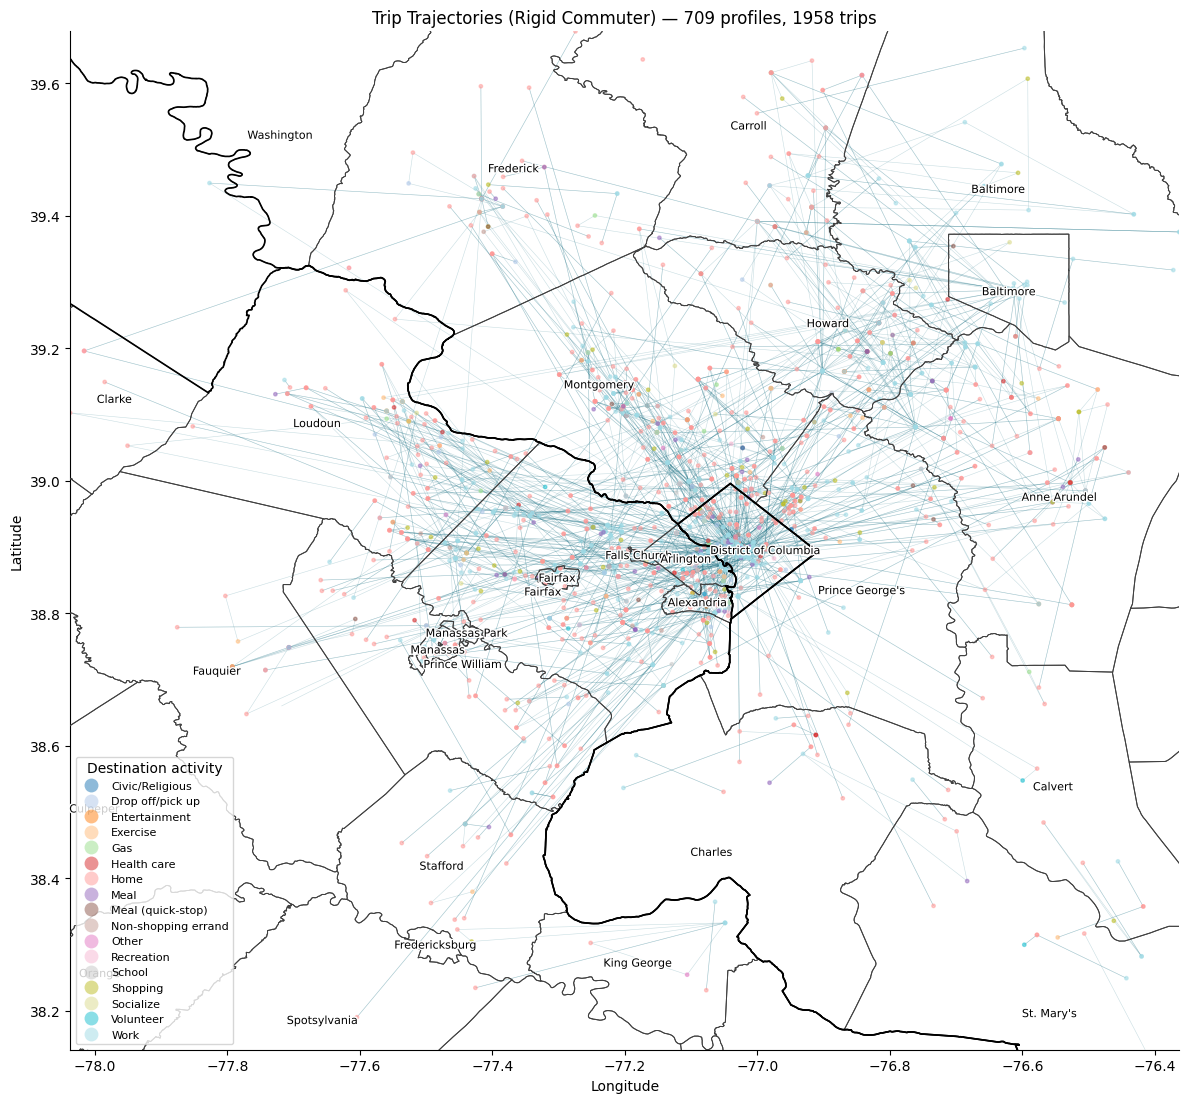

In [68]:
for archetype, archetype_profiles in profiles_by_archetype:
    plot_trip_geo(archetype_profiles, title_prefix = f"Trip Trajectories ({archetype.value})")

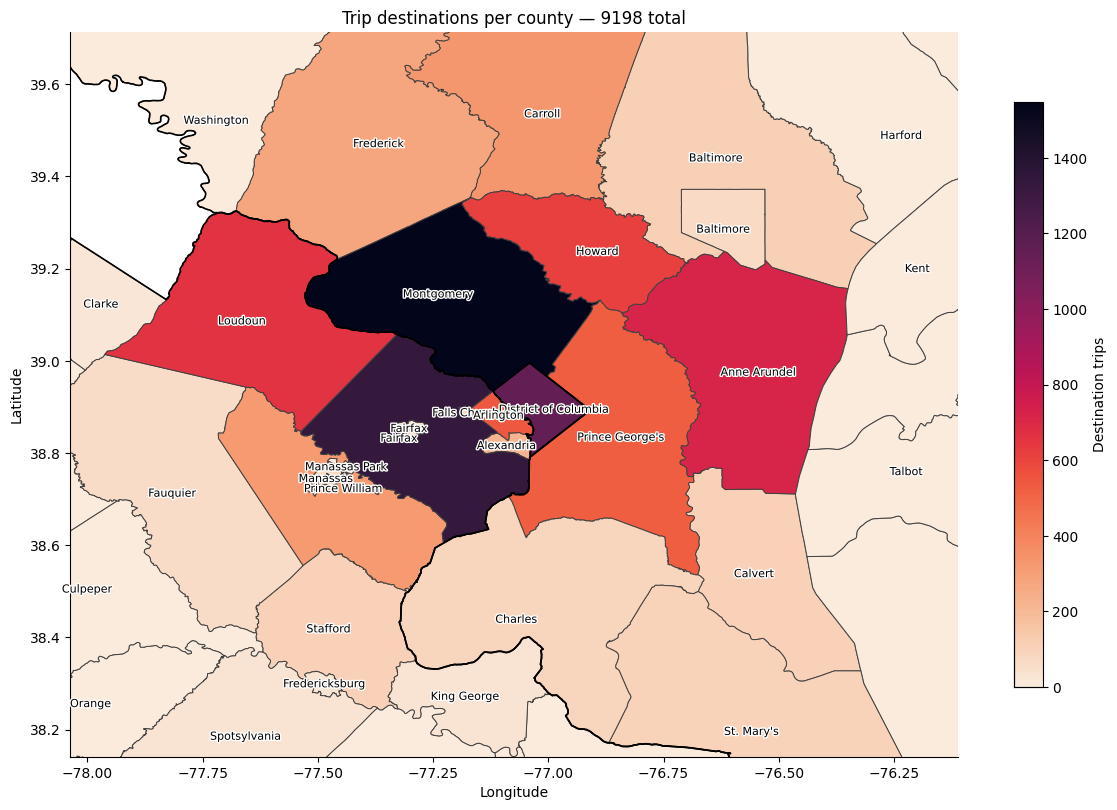

In [69]:
def plot_dest_heatmap(profiles: list[Profile], title_prefix: str = "Trip destinations per county") -> None:
    dest_records = [
        {"geometry": Point(trip.dest_coords)}
        for profile in profiles
        for trip in profile.trips
        if trip.dest_coords is not None
    ]
    if not dest_records:
        return
    dest_gdf = gpd.GeoDataFrame(dest_records, crs = "EPSG:4326")

    joined = gpd.sjoin(dest_gdf, counties_gdf[["GEOID", "geometry"]], how = "left", predicate = "within")
    counts = joined.groupby("GEOID").size().rename("dest_trips")

    counties_with_counts = counties_gdf.merge(counts, on = "GEOID", how = "left")
    counties_with_counts["dest_trips"] = counties_with_counts["dest_trips"].fillna(0).astype(int)

    pt_min_x, pt_min_y, pt_max_x, pt_max_y = dest_gdf.total_bounds
    pad = 0.5
    counties_view = counties_with_counts.cx[pt_min_x - pad:pt_max_x + pad, pt_min_y - pad:pt_max_y + pad]
    states_view = states_gdf.cx[pt_min_x - pad:pt_max_x + pad, pt_min_y - pad:pt_max_y + pad]

    fig, ax = plt.subplots(figsize = (12, 12))
    counties_view.plot(
        ax = ax,
        column = "dest_trips",
        cmap = "rocket_r",
        legend = True,
        legend_kwds = {"label": "Destination trips", "shrink": 0.5},
        edgecolor = "#404040",
        linewidth = 0.7,
        zorder = 1
    )
    states_view.boundary.plot(ax = ax, color = "black", linewidth = 1.2, zorder = 2)
    for _, county_row in counties_view.iterrows():
        point = county_row.geometry.representative_point()
        ax.annotate(
            county_row["NAME"],
            xy = (point.x, point.y),
            ha = "center",
            va = "center",
            fontsize = 8,
            color = "black",
            zorder = 3,
            path_effects = [pe.withStroke(linewidth = 2, foreground = "white")]
        )

    ax.set_xlim(pt_min_x, pt_max_x)
    ax.set_ylim(pt_min_y, pt_max_y)
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title_prefix} — {int(counts.sum())} total")
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_dest_heatmap(filtered_profiles)

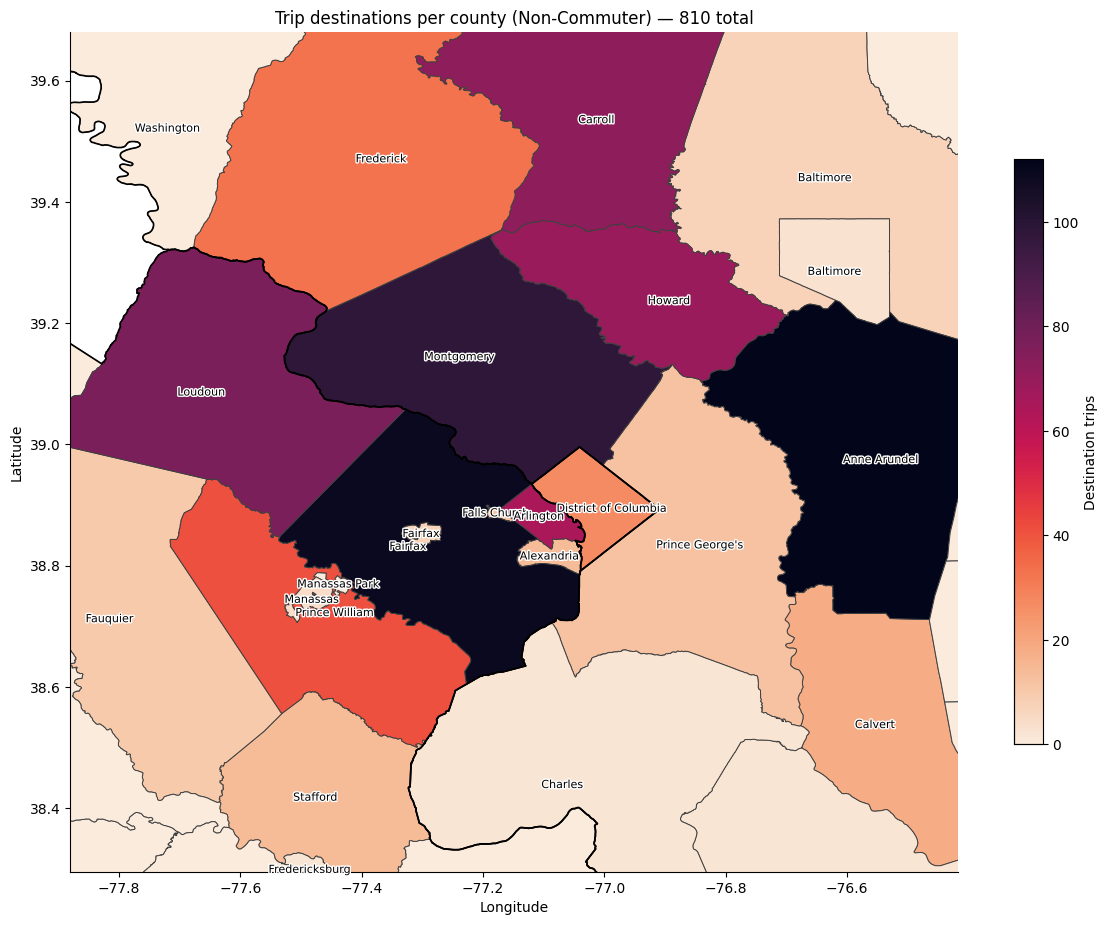

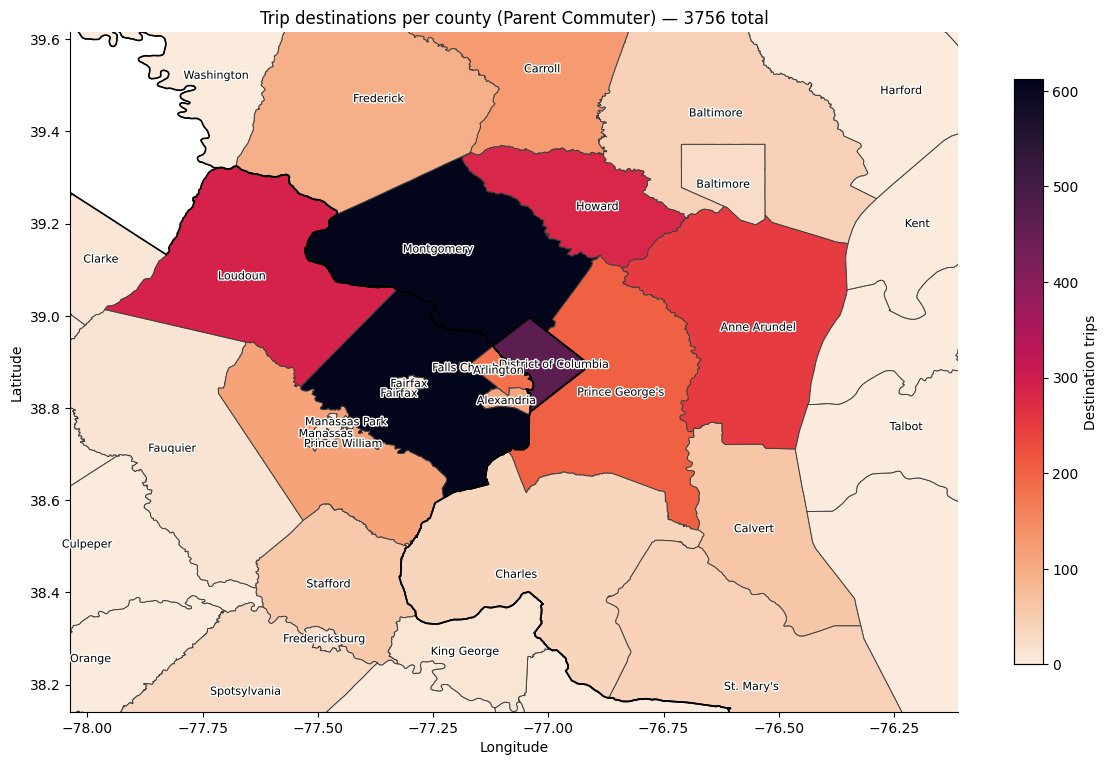

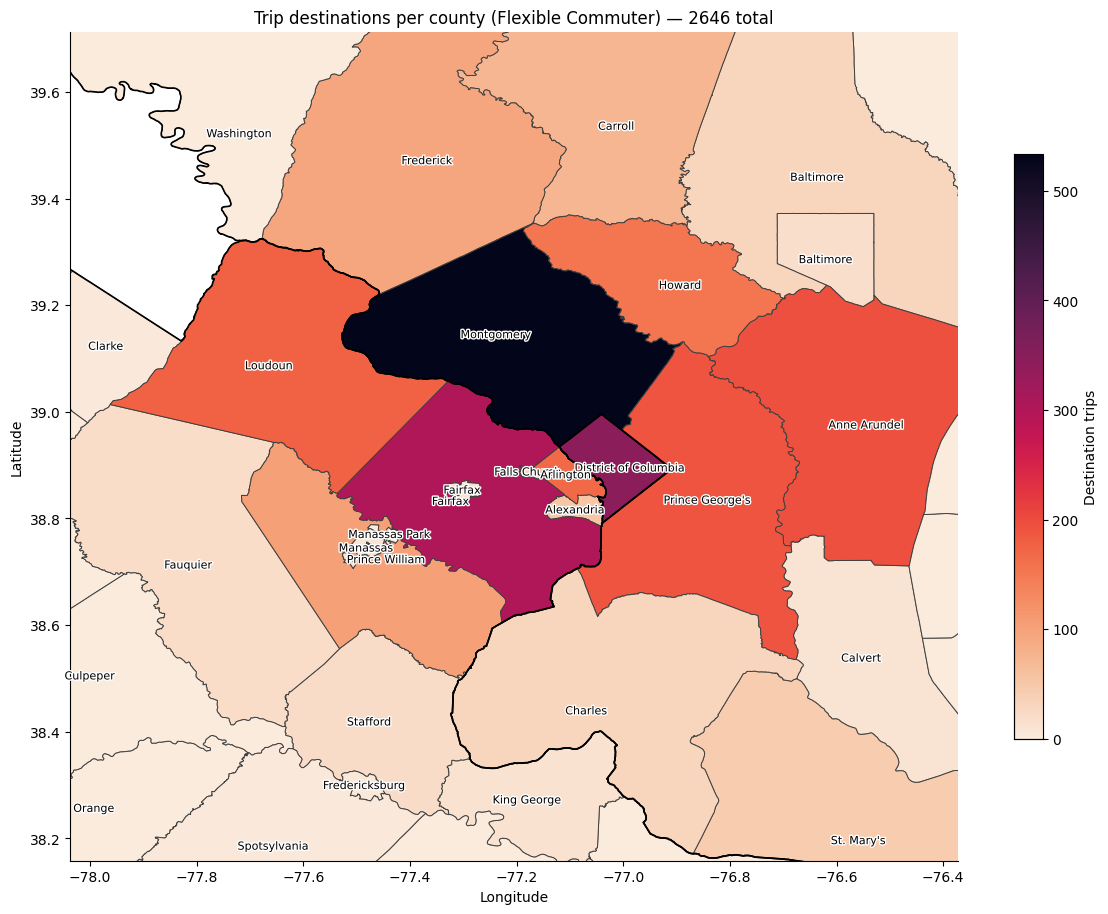

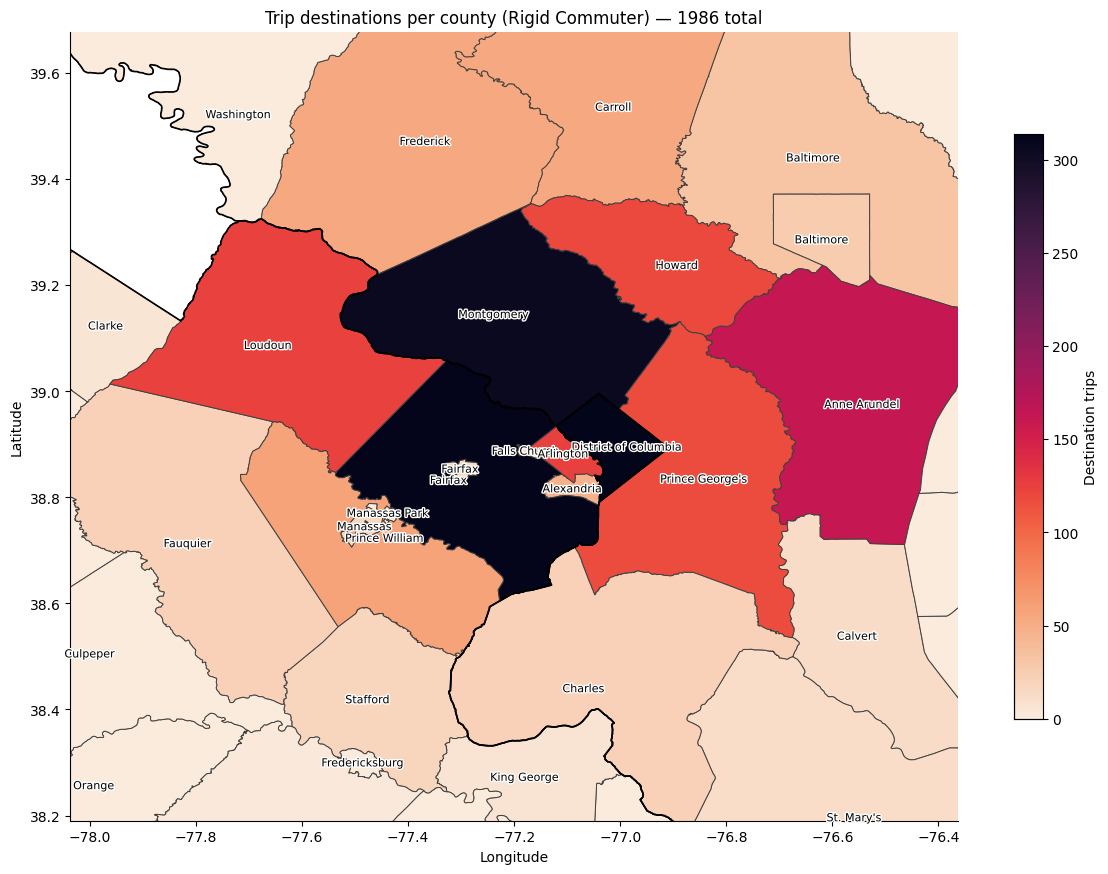

In [70]:
for archetype, archetype_profiles in profiles_by_archetype:
    plot_dest_heatmap(archetype_profiles, title_prefix = f"Trip destinations per county ({archetype.value})")

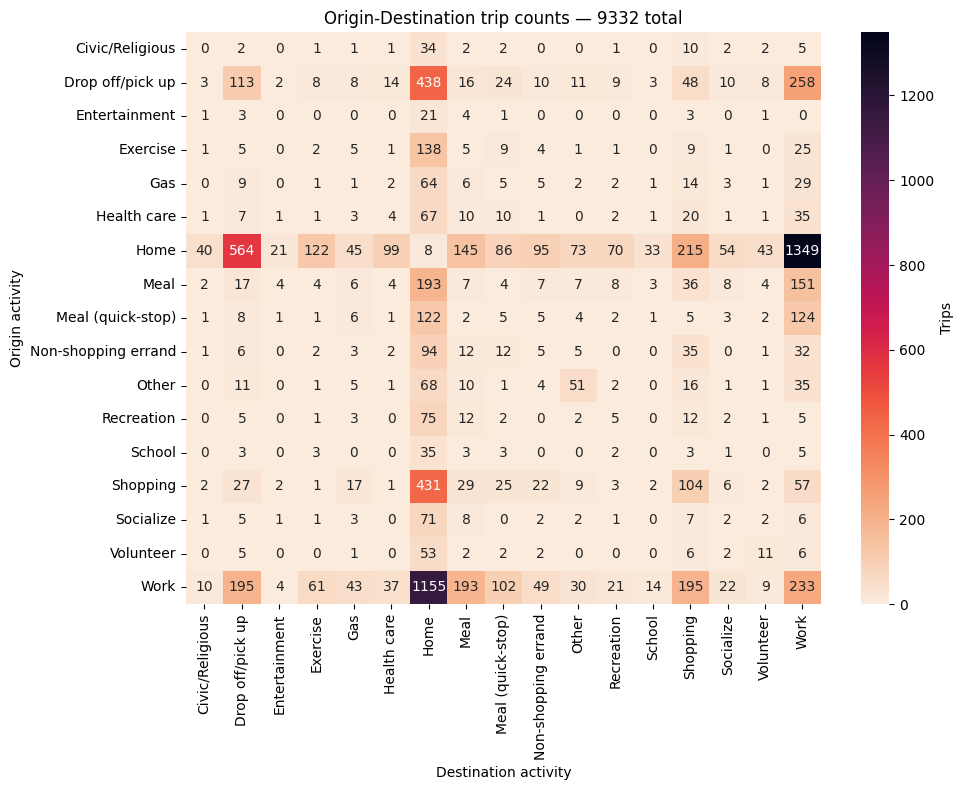

In [71]:
def plot_od_heatmap(profiles: list[Profile], title_prefix: str = "Origin-Destination trip counts") -> None:
    pairs = [
        (trip.origin_activity, trip.dest_activity)
        for profile in profiles
        for trip in profile.trips
        if trip.origin_activity is not None and trip.dest_activity is not None
    ]
    if not pairs:
        return
    od_df = pd.DataFrame(pairs, columns = ["origin", "dest"])
    matrix = pd.crosstab(od_df["origin"], od_df["dest"])

    fig, ax = plt.subplots(figsize = (10, 8))
    sns.heatmap(matrix, annot = True, fmt = "d", cmap = "rocket_r", ax = ax, cbar_kws = {"label": "Trips"})
    ax.set_xlabel("Destination activity")
    ax.set_ylabel("Origin activity")
    ax.set_title(f"{title_prefix} — {len(pairs)} total")
    plt.tight_layout()
    plt.show()

plot_od_heatmap(filtered_profiles)

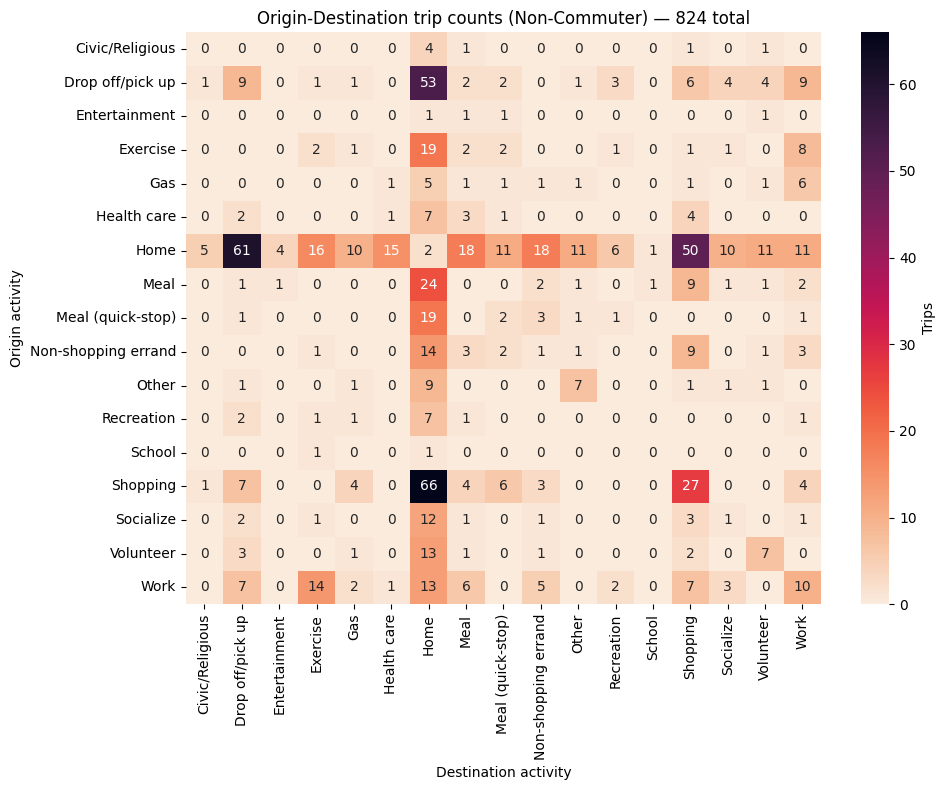

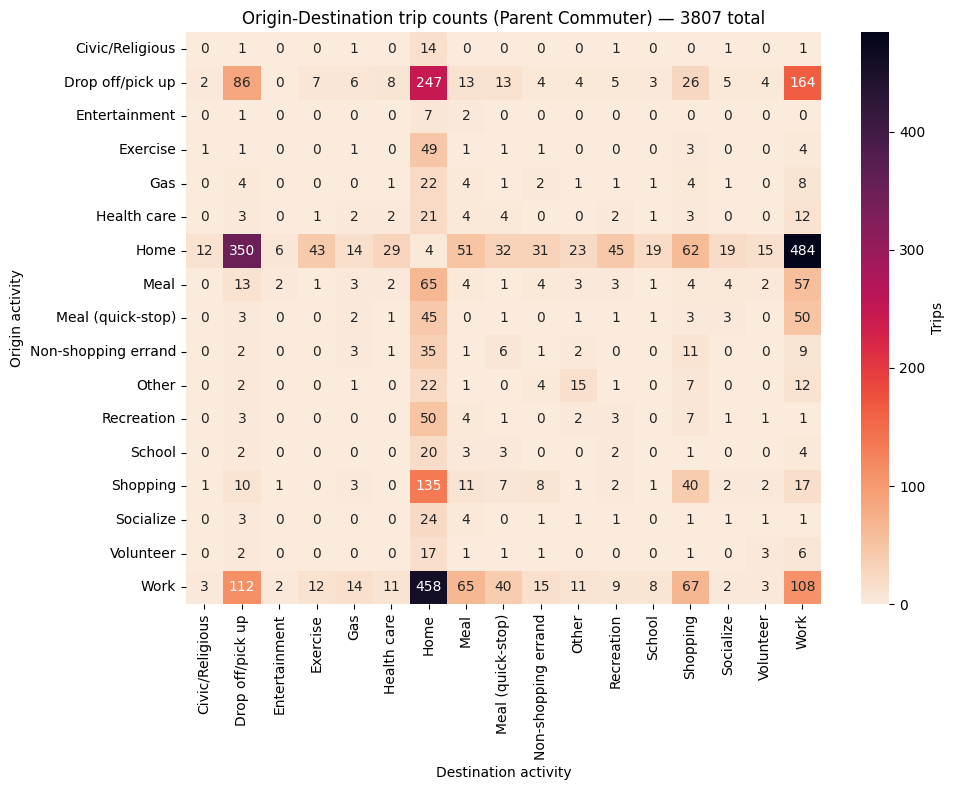

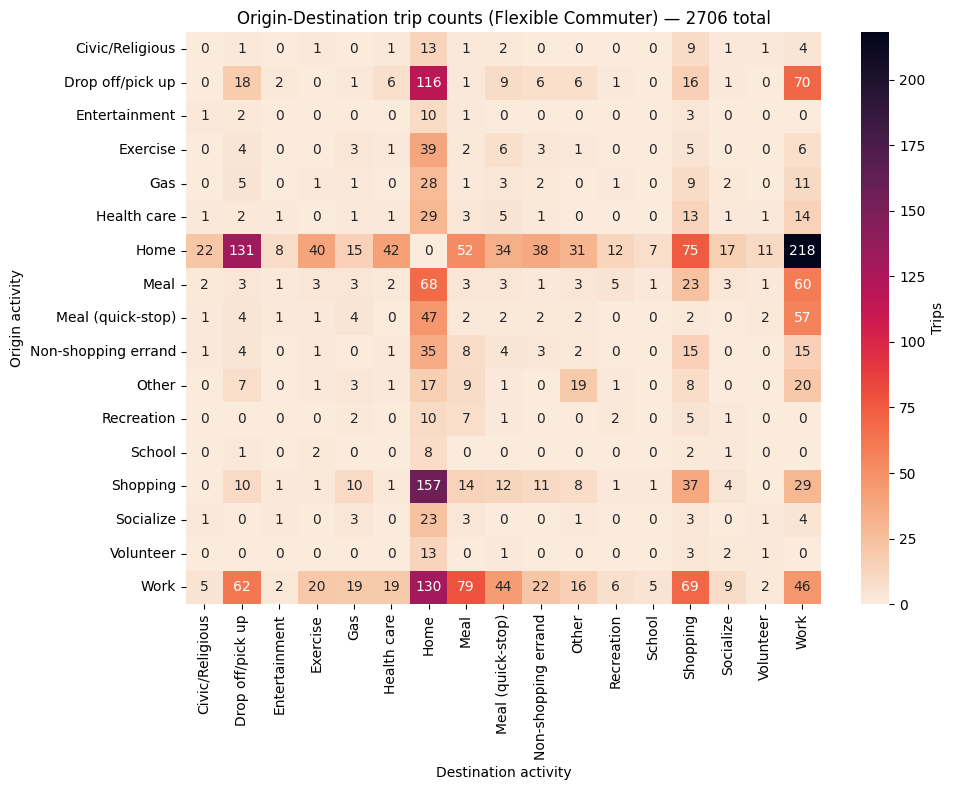

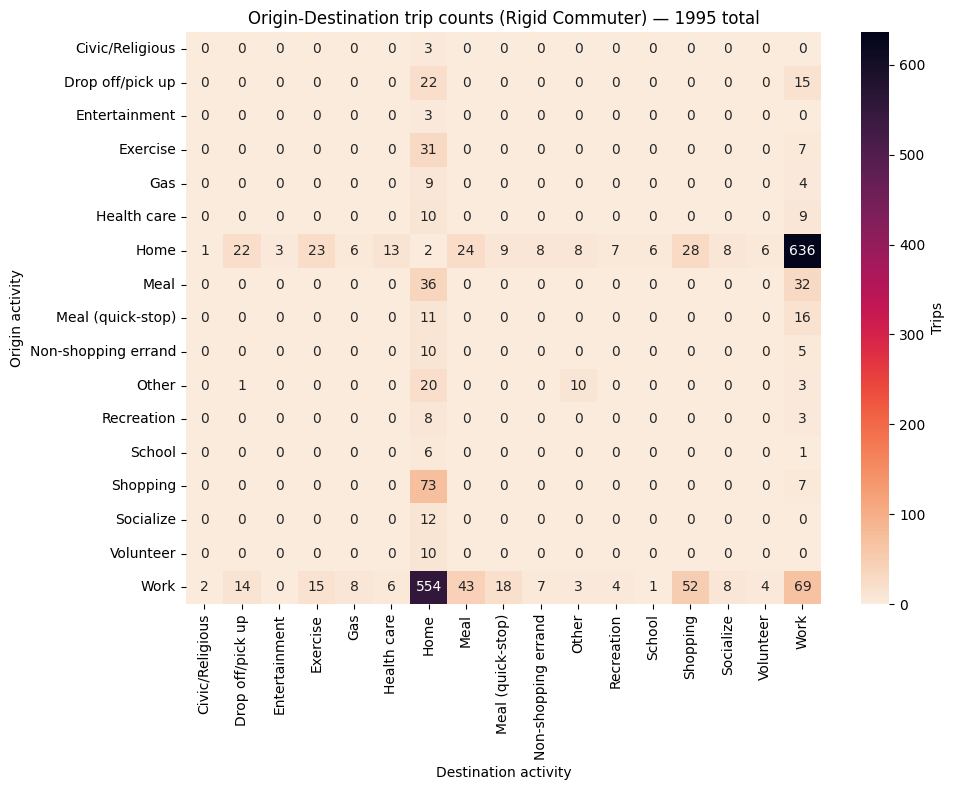

In [72]:
for archetype, archetype_profiles in profiles_by_archetype:
    plot_od_heatmap(archetype_profiles, title_prefix = f"Origin-Destination trip counts ({archetype.value})")

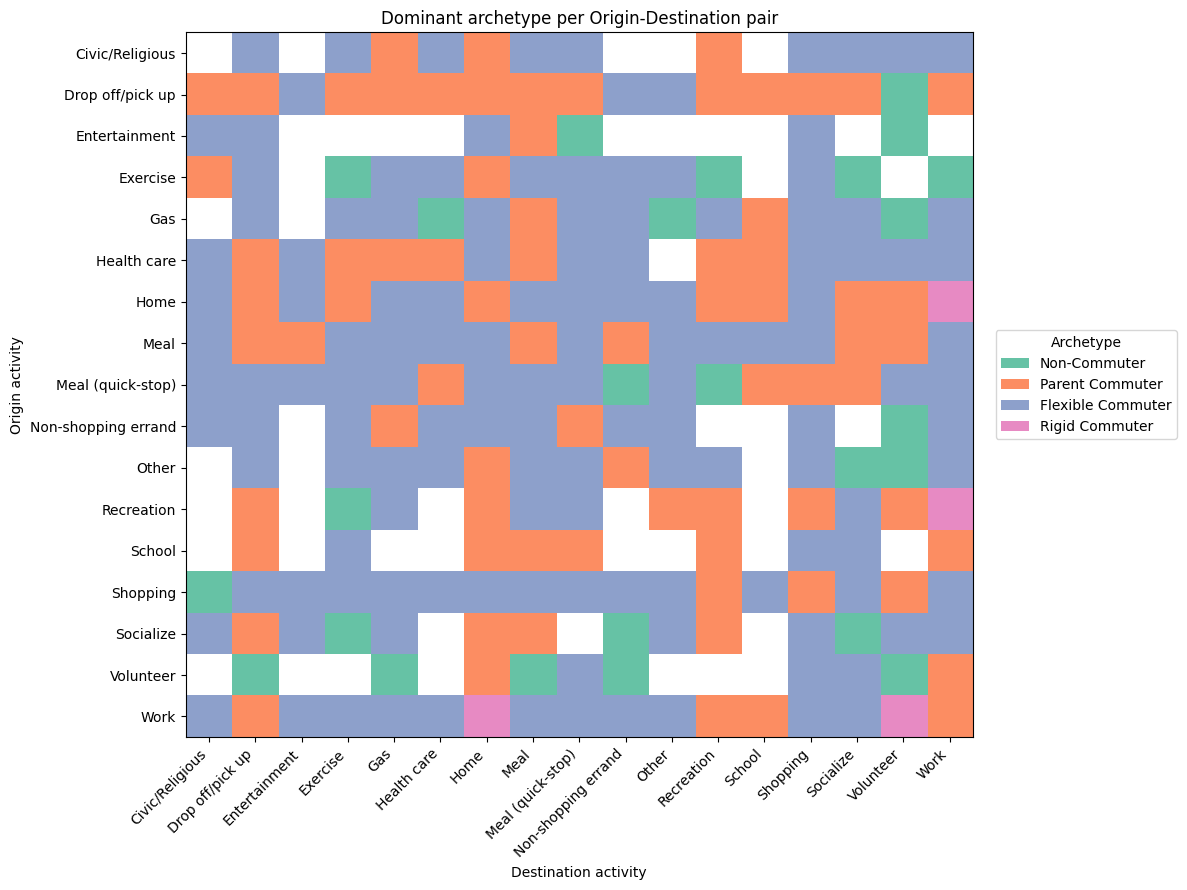

In [73]:
od_records = [
    {"archetype": profile.archetype.value, "origin": trip.origin_activity, "dest": trip.dest_activity}
    for profile in filtered_profiles
    for trip in profile.trips
    if trip.origin_activity is not None and trip.dest_activity is not None
]
od_df = pd.DataFrame(od_records)

counts = pd.crosstab([od_df["origin"], od_df["dest"]], od_df["archetype"])
dominant = counts.idxmax(axis = 1).rename("archetype")

dominant_matrix = dominant.unstack("dest")

archetype_order = [archetype.value for archetype in Archetype]
archetype_to_code = {value: index for index, value in enumerate(archetype_order)}
code_matrix = dominant_matrix.map(lambda value: archetype_to_code.get(value, -1) if isinstance(value, str) else -1)

palette = sns.color_palette("Set2", n_colors = len(archetype_order))
cmap = ListedColormap(palette)

fig, ax = plt.subplots(figsize = (12, 9))
masked = code_matrix.where(code_matrix >= 0)
ax.imshow(masked.values, cmap = cmap, vmin = 0, vmax = len(archetype_order) - 1, aspect = "auto")

ax.set_xticks(range(len(code_matrix.columns)))
ax.set_xticklabels(code_matrix.columns, rotation = 45, ha = "right")
ax.set_yticks(range(len(code_matrix.index)))
ax.set_yticklabels(code_matrix.index)
ax.set_xlabel("Destination activity")
ax.set_ylabel("Origin activity")
ax.set_title("Dominant archetype per Origin-Destination pair")

legend_handles = [Patch(facecolor = palette[index], label = value) for index, value in enumerate(archetype_order)]
ax.legend(handles = legend_handles, title = "Archetype", loc = "center left", bbox_to_anchor = (1.02, 0.5))

plt.tight_layout()
plt.show()